# **Hotel Reservation Cancellation Prediction using ANN**

**🧩 Section 1: Import Libraries**

In [1]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TensorFlow / Keras for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


**📂 Section 2: Load & Explore Dataset
python**


In [4]:
# Load the dataset

import kagglehub
ryanholbrook_dl_course_data_path = kagglehub.dataset_download('ryanholbrook/dl-course-data')

df = pd.read_csv(f'{ryanholbrook_dl_course_data_path}/hotel.csv')

X = df.copy()
y = X.pop('is_canceled')
# Preview the data
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 🧠 Quick EDA (Exploratory Data Analysis)

Let’s check:
- The shape of the data
- Missing values
- Target class distribution


Dataset shape: (119390, 32)

Missing values:
 hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent      

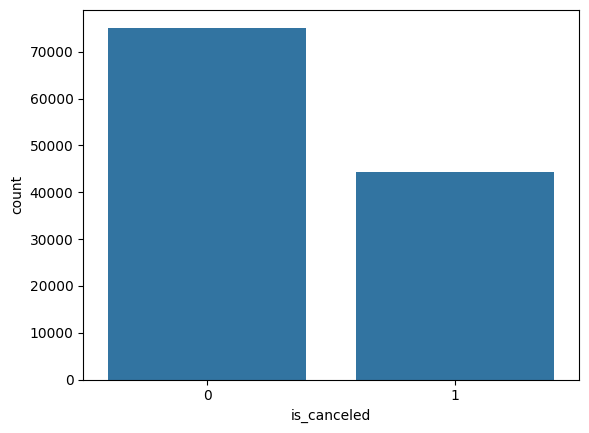

In [6]:
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['is_canceled'].value_counts())
sns.countplot(data=df, x='is_canceled');


**🛠 Section 3: Data Preprocessing**

### 🧹 Preprocessing Steps:
1. Encode categorical variables
2. Scale numerical features
3. Handle missing data
4. Encode target
5. Split data


In [8]:
# Encode target
# df['booking_status'] = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0}) # Original line causing the error
df['is_canceled'] = df['is_canceled'].map({1: 1, 0: 0})  # Map 'is_canceled' column instead

# Label encode categorical features
cat_cols = df.select_dtypes(include='object').columns

df_encoded = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])

# Feature-target split
#X = df_encoded.drop('booking_status', axis=1) # Original line causing the error
X = df_encoded.drop('is_canceled', axis=1)  # Drop 'is_canceled' column instead
y = df_encoded['is_canceled']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-validation-test split: 70-15-15
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

**🔧 Section 4: Build a Baseline ANN
markdown**

### 📊 Baseline Model (Simple Architecture)
Let’s begin with a small network to get baseline metrics.


In [9]:
baseline_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = baseline_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), verbose=0)

# Evaluate
loss, acc = baseline_model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6311 - loss: nan
Test Accuracy: 0.6295717358589172


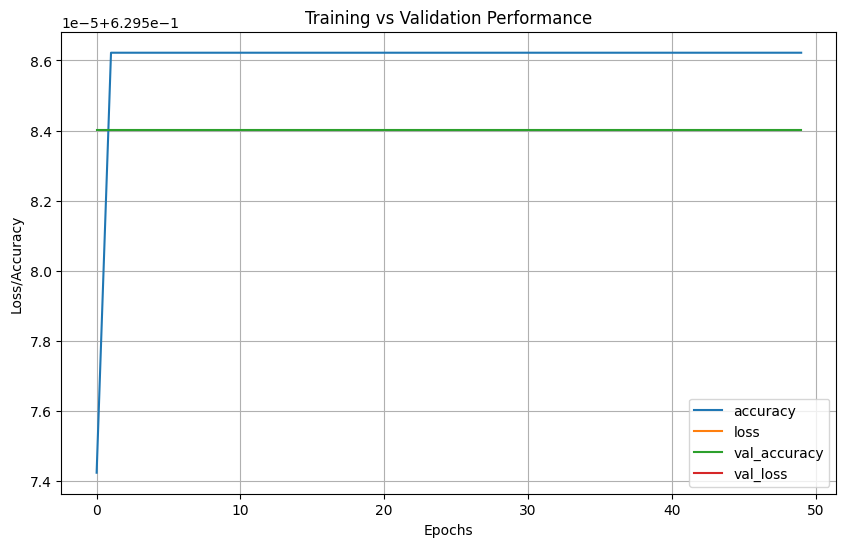

In [10]:
# Plot learning curves
def plot_history(hist):
    pd.DataFrame(hist.history).plot(figsize=(10, 6))
    plt.grid(True)
    plt.title("Training vs Validation Performance")
    plt.xlabel("Epochs")
    plt.ylabel("Loss/Accuracy")
    plt.show()

plot_history(history)


**📉 Section 5: Generate Underfitting
markdown**

### 🧪 Underfitting Model
One tiny layer, few epochs — let’s see how the model performs poorly.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


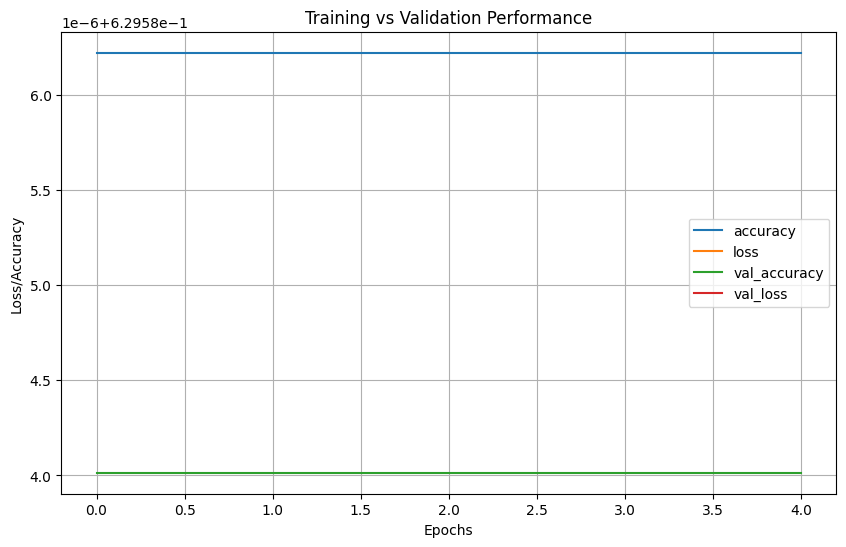

In [11]:
underfit_model = Sequential([
    Dense(4, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

underfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

underfit_history = underfit_model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), verbose=0)
plot_history(underfit_history)


### 🔧 Fix: Increase capacity
Let’s now fix underfitting by making a deeper network and training longer.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


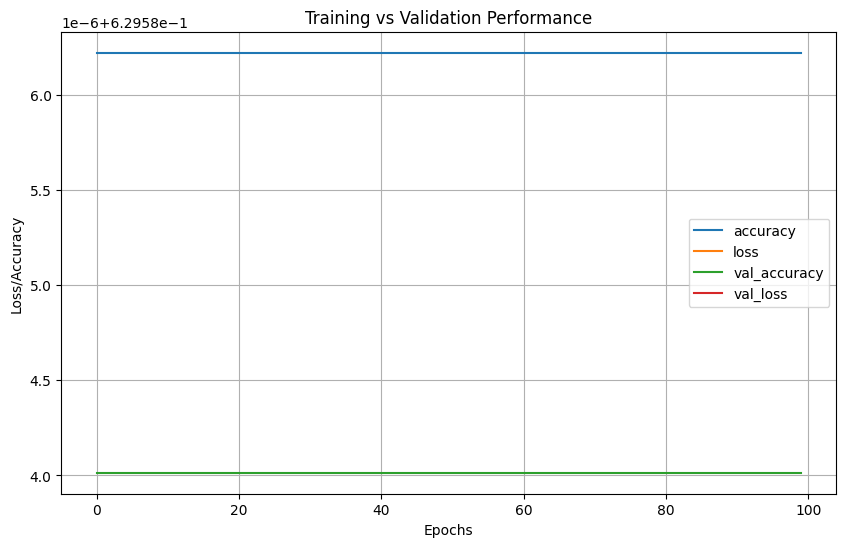

In [12]:
fixed_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

fixed_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

fixed_history = fixed_model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), verbose=0)
plot_history(fixed_history)


**📈 Section 6: Generate Overfitting
markdown**

### 🎯 Overfitting Model
Too many layers + neurons — overkill!


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


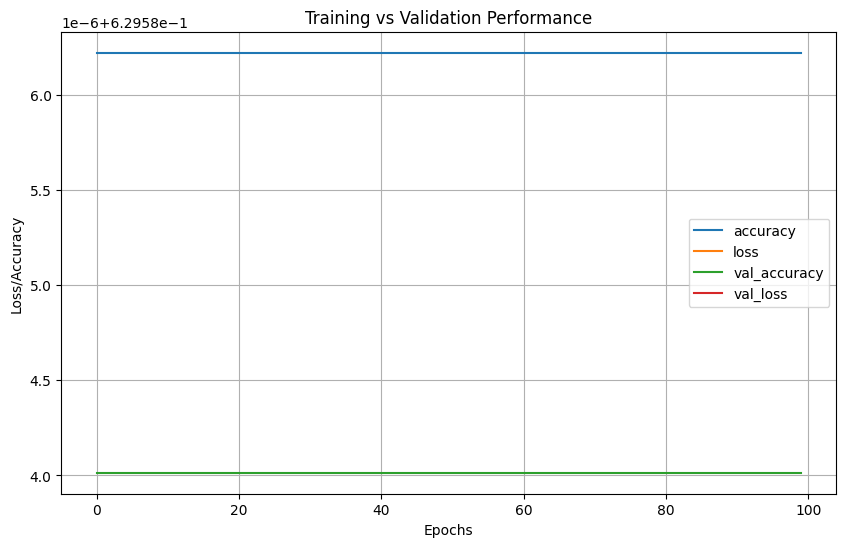

In [13]:
overfit_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

overfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

overfit_history = overfit_model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), verbose=0)
plot_history(overfit_history)


**🔄 Section 7: Fix Overfitting with Regularization
python**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


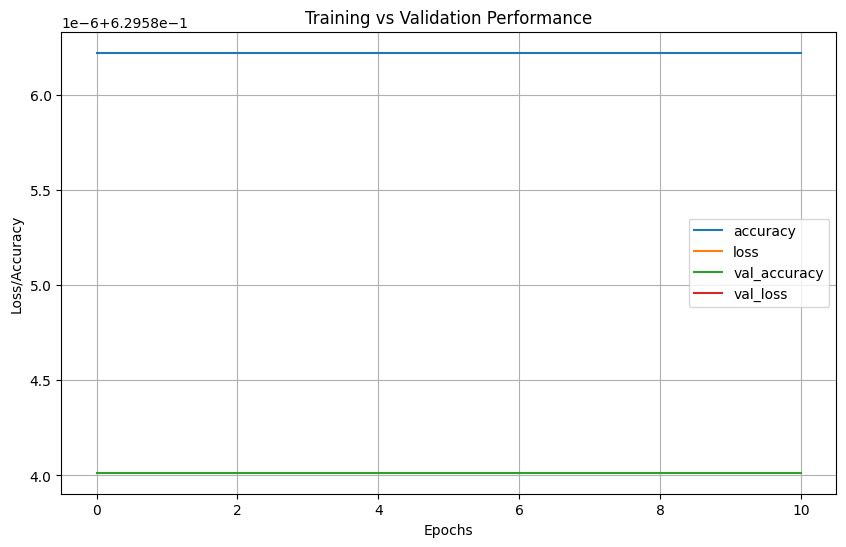

In [14]:
# Add Dropout + EarlyStopping
regularized_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

regularized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

regularized_history = regularized_model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val),
                                            callbacks=[early_stop], verbose=0)
plot_history(regularized_history)


**⚙️ Section 8: Experiment with Batch Normalization
python**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


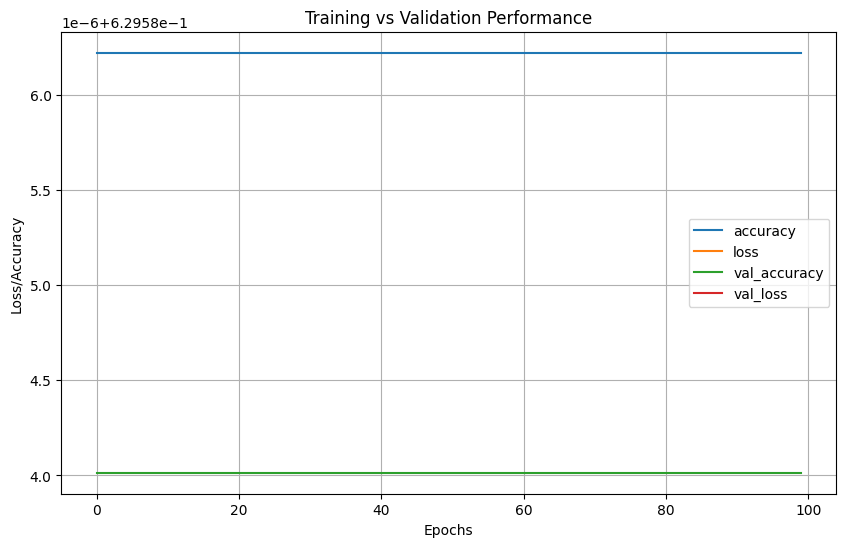

In [15]:
# With Batch Normalization
bn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

bn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

bn_history = bn_model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), verbose=0)
plot_history(bn_history)


**📊 Section 9: Final Evaluation
python**

In [16]:
# Final model eval
y_pred = (bn_model.predict(X_test) > 0.5).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.63      1.00      0.77     11275
           1       0.00      0.00      0.00      6634

    accuracy                           0.63     17909
   macro avg       0.31      0.50      0.39     17909
weighted avg       0.40      0.63      0.49     17909

Confusion Matrix:
 [[11275     0]
 [ 6634     0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **✍️ Section 10: Reflection & Learnings markdown**

## 🧠 Reflection

**Underfitting** was caused by a too-simple model with few layers and neurons. We fixed it by adding layers and training longer.

**Overfitting** emerged with large networks. We observed training accuracy skyrocketing while validation stagnated. Dropout and EarlyStopping helped mitigate it.

**Batch Normalization** helped stabilize and speed up learning.

**Advice to Past Me**:
- Start simple
- Monitor validation curves closely
- Regularize aggressively if needed
- Use BatchNorm when layers are deep
